# **Payment System Market Forecasting**

> **Other Forecasting Approaches: Holt-Winters & Bayesian Time-Series Models**

# Import libraries

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from statsmodels.tsa.seasonal import seasonal_decompose

from bcrp_analytics.bcrp_analyzer import BCRP_ANALYZER
from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

# Pandas display options
pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# Matplotlib theme
plt.style.use("mocha")

## 1. **Load data: Monto y número de operaciones procesadas por los adquirentes y facilitadores de pago por segmento de comercio (millones de soles y miles de operaciones)**

In [2]:
# series to test
adquirentes_facilitadores_pago_series = {
    "PN42689EM": "monto_total_adqfac",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
}

In [3]:
df_adquirentes_facilitadores = build_bcrp_dataset(adquirentes_facilitadores_pago_series)
df_adquirentes_facilitadores.head()

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:158: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn(


,period,monto_total_adqfac,alto_valor,bajo_valor
0,2026-03-01,"13,167.96","478,458.55","417,155.45"
1,2026-02-01,"11,697.08","411,779.84","377,297.19"
2,2026-01-01,"12,252.01","398,930.84","394,384.29"
3,2025-12-01,"14,927.05","462,444.46","458,953.59"
4,2025-11-01,"12,200.23","398,541.09","374,481.11"


# Holt - Winters

In [11]:
df_forecast = df_adquirentes_facilitadores.sort_values("period").set_index("period")

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

serie = df_forecast["monto_total_adqfac"].dropna()

model = ExponentialSmoothing(
    serie,
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
)

results = model.fit()

forecast = results.forecast(6)

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [13]:
print(forecast)

2026-04-01   12,223.62
2026-05-01   13,183.67
2026-06-01   12,697.88
2026-07-01   14,590.84
2026-08-01   13,766.16
2026-09-01   12,770.00
Freq: MS, dtype: float64


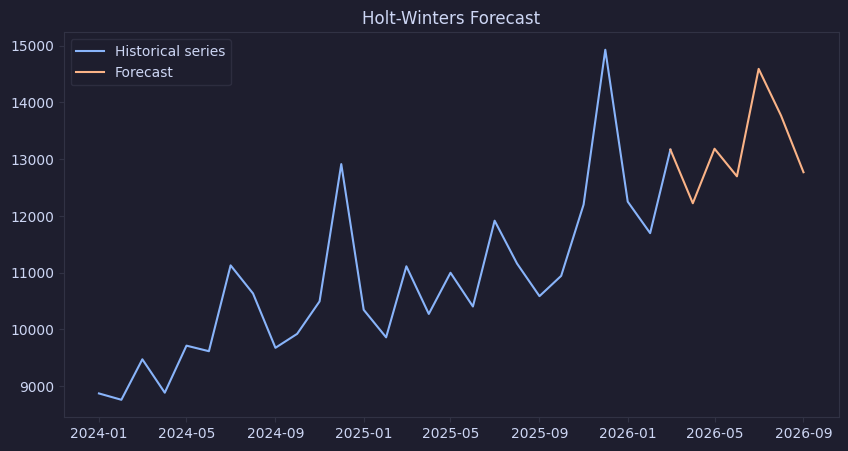

In [15]:
plt.figure(figsize=(10, 5))

# Historical series
plt.plot(
    serie.index,
    serie,
    label="Historical series",
)

# Connect last historical point with forecast
forecast_index = [serie.index[-1]] + list(forecast.index)
forecast_values = [serie.iloc[-1]] + list(forecast.values)

plt.plot(
    forecast_index,
    forecast_values,
    label="Forecast",
)

plt.legend()
plt.title("Holt-Winters Forecast")
plt.show()